In [1]:
import pcdl
import numpy as np
from numpy.linalg import norm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to p

In [2]:
def measure_speeds(data, ids, times, time_tick):
    speeds = []
    average_speeds_in_time = [[] for _ in range(len(times)-1)]
    for cell in tqdm(ids):
        positions = data[data.ID == cell].loc[:, ['time', 'position_x', 'position_y']]
        trajectory = []
        prev_position = positions[positions.time == times[0]].loc[:, ['position_x', 'position_y']].values
        if len(prev_position) > 0:
            prev_position = prev_position[0]
            for i_time, time in enumerate(times[1:]):
                new_position = positions[positions.time == time].loc[:, ['position_x', 'position_y']].values
                if len(new_position) > 0:
                    new_position = new_position[0]
                    
                    speed = norm(prev_position- new_position)
                    speed_in_minutes = speed/time_tick
                    speeds.append(speed_in_minutes)
                    
                    average_speeds_in_time[i_time].append(speed_in_minutes)
                    prev_position = new_position
                else: 
                    break
    for i_time in range(len(times)-1):
        average = np.mean(average_speeds_in_time[i_time])
        average_speeds_in_time[i_time] = average

    return speeds, average_speeds_in_time

In [3]:
def measure_distances(data, ids, times, encounter_distance = 50):
    avg_distances = []
    encounters = []
    for time in tqdm(times):
        cells = list(set(data[data.time == time].loc[:, 'ID']))
        distances = []
        encounter = 0    
        for cell in cells:
            position_cell = data[(data.time == time) & (data.ID == cell)].loc[:, ['position_x', 'position_y']].values[0]
            positions_other_cells = data[(data.time == time) & (data.ID != cell)].loc[:, ['position_x', 'position_y']].values
    
            for pos in positions_other_cells:
                dist = norm(position_cell-pos[0])
                if dist < encounter_distance:
                    encounter += 1
                distances.append(norm(position_cell-pos[0]))
    
        avg_distances.append(np.mean(distances))
        encounters.append(encounter)
    return avg_distances, encounters

In [4]:
mcdsts = pcdl.TimeSeries('output/', verbose=False)

In [5]:
data = mcdsts.get_cell_df()

In [6]:
# list(data.columns)

In [7]:
data = data.loc[:, ['ID', 'time', 'position_x', 'position_y']]

In [8]:
ids = list(set(data.loc[:, 'ID']))
times = sorted(list(set(data.loc[:, 'time'])))
time_tick = times[1] - times[0]

In [9]:
print(f"Simulation loaded: {len(ids)} cells, {len(times)} timepoints")

Simulation loaded: 700 cells, 49 timepoints


### Measuring average speed

In [10]:
speeds, average_speeds_in_time = measure_speeds(data, ids, times, time_tick)

  0%|          | 0/700 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Average speed')

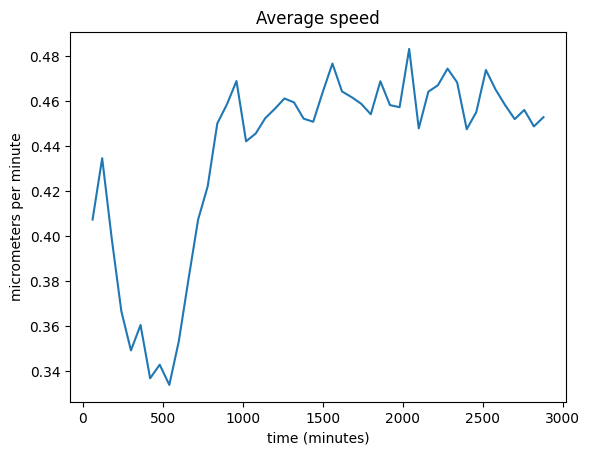

In [11]:
plt.plot(times[1:], average_speeds_in_time)
plt.xlabel("time (minutes)")
plt.ylabel("micrometers per minute")
plt.title("Average speed")

Text(0.5, 1.0, 'Distribution of measured speeds')

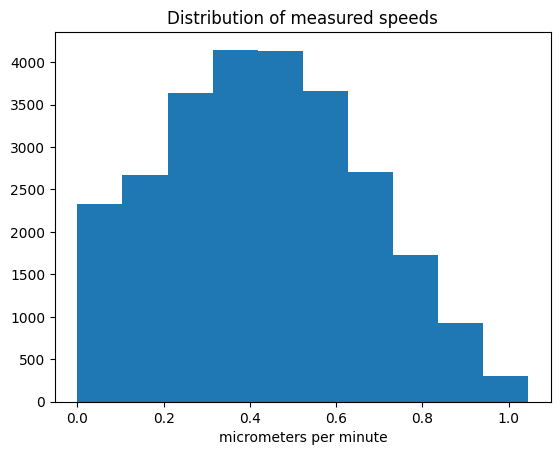

In [12]:
plt.hist(speeds)
plt.xlabel("micrometers per minute")
plt.title("Distribution of measured speeds")

### Measuring average distance and number of encounters

Note: Encounters are define as being under 50 micrometers

In [13]:
encounter_distance = 50
avg_distances, encounters = measure_distances(data, ids, times, encounter_distance)

  0%|          | 0/49 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Average distance between cells')

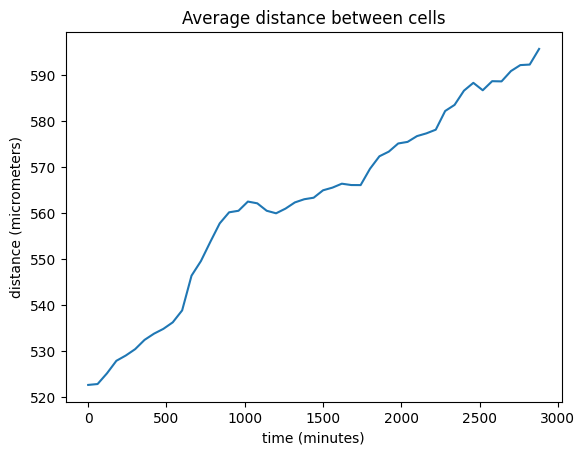

In [14]:
plt.plot(times, avg_distances)
plt.xlabel("time (minutes)")
plt.ylabel("distance (micrometers)")
plt.title("Average distance between cells")

Text(0.5, 1.0, 'Encounters between cells')

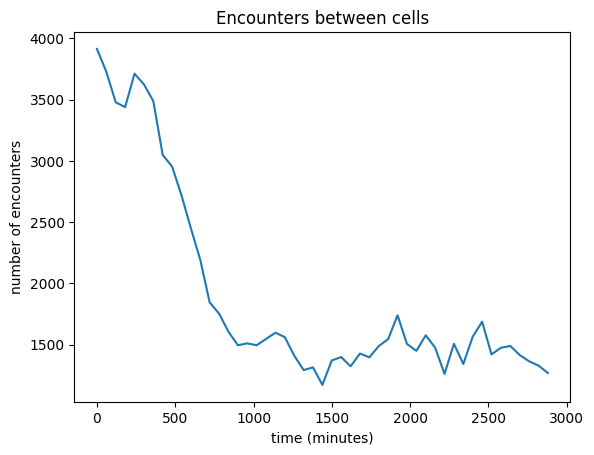

In [15]:
plt.plot(times, encounters)
plt.xlabel("time (minutes)")
plt.ylabel("number of encounters")
plt.title("Encounters between cells")

## With persistence time = 0

In [16]:
mcdsts = pcdl.TimeSeries('output_persistence_0//', verbose=False)
data = mcdsts.get_cell_df()
data = data.loc[:, ['ID', 'time', 'position_x', 'position_y']]
ids = list(set(data.loc[:, 'ID']))
times = sorted(list(set(data.loc[:, 'time'])))
time_tick = times[1] - times[0]
print(f"Simulation loaded: {len(ids)} cells, {len(times)} timepoints")

Simulation loaded: 719 cells, 49 timepoints


In [17]:
speeds, average_speeds_in_time = measure_speeds(data, ids, times, time_tick)                      

  0%|          | 0/719 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Average speed')

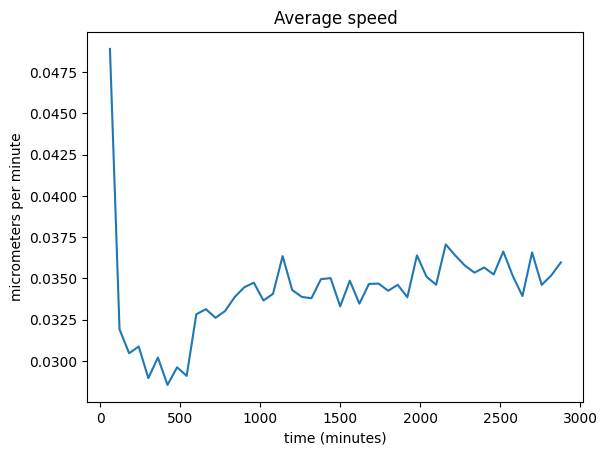

In [18]:
plt.plot(times[1:], average_speeds_in_time)
plt.xlabel("time (minutes)")
plt.ylabel("micrometers per minute")
plt.title("Average speed")

Text(0.5, 1.0, 'Distribution of measured speeds')

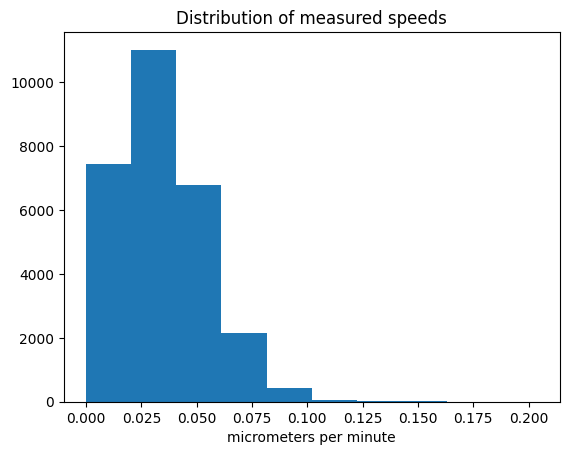

In [19]:
plt.hist(speeds)
plt.xlabel("micrometers per minute")
plt.title("Distribution of measured speeds")

In [20]:
encounter_distance = 50
avg_distances, encounters = measure_distances(data, ids, times, encounter_distance)

  0%|          | 0/49 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Average distance between cells')

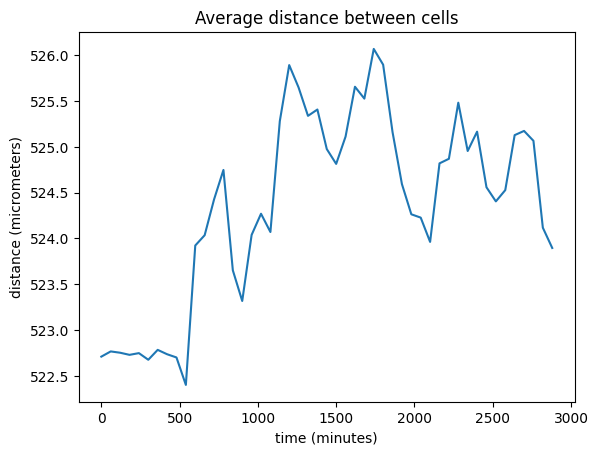

In [21]:
plt.plot(times, avg_distances)
plt.xlabel("time (minutes)")
plt.ylabel("distance (micrometers)")
plt.title("Average distance between cells")

Text(0.5, 1.0, 'Encounters between cells')

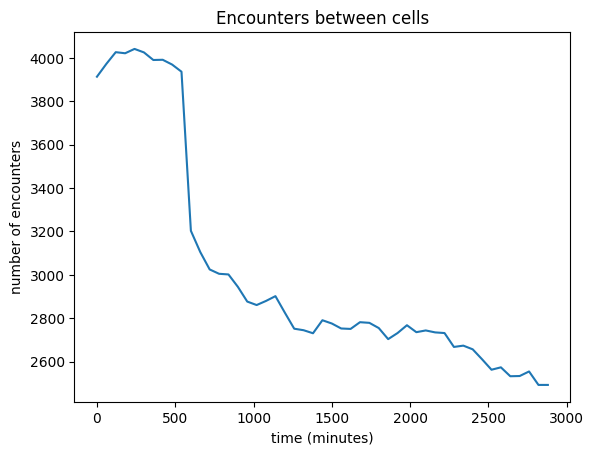

In [22]:
plt.plot(times, encounters)
plt.xlabel("time (minutes)")
plt.ylabel("number of encounters")
plt.title("Encounters between cells")

## With persistence time = inf

In [23]:
mcdsts = pcdl.TimeSeries('output_persistence_inf//', verbose=False)
data = mcdsts.get_cell_df()
data = data.loc[:, ['ID', 'time', 'position_x', 'position_y']]
ids = list(set(data.loc[:, 'ID']))
times = sorted(list(set(data.loc[:, 'time'])))
time_tick = times[1] - times[0]
print(f"Simulation loaded: {len(ids)} cells, {len(times)} timepoints")

Simulation loaded: 706 cells, 49 timepoints


In [24]:
speeds, average_speeds_in_time = measure_speeds(data, ids, times, time_tick)                      

  0%|          | 0/706 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Average speed')

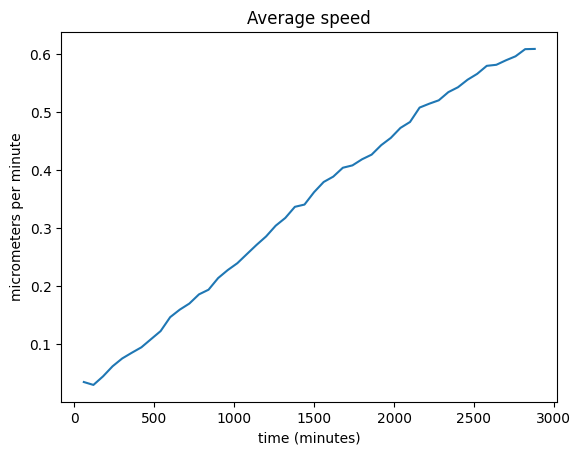

In [25]:
plt.plot(times[1:], average_speeds_in_time)
plt.xlabel("time (minutes)")
plt.ylabel("micrometers per minute")
plt.title("Average speed")

Text(0.5, 1.0, 'Distribution of measured speeds')

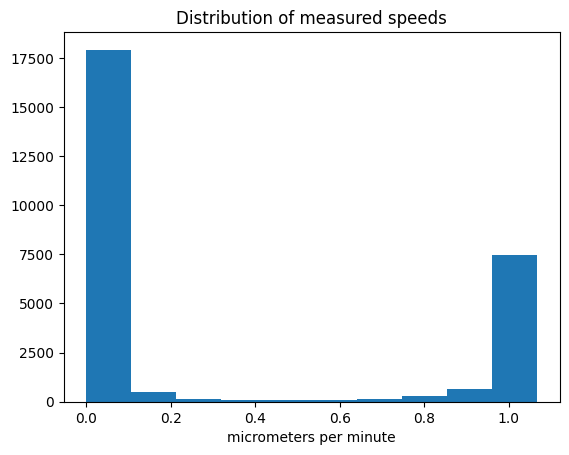

In [26]:
plt.hist(speeds)
plt.xlabel("micrometers per minute")
plt.title("Distribution of measured speeds")

In [27]:
encounter_distance = 50
avg_distances, encounters = measure_distances(data, ids, times, encounter_distance)

  0%|          | 0/49 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Average distance between cells')

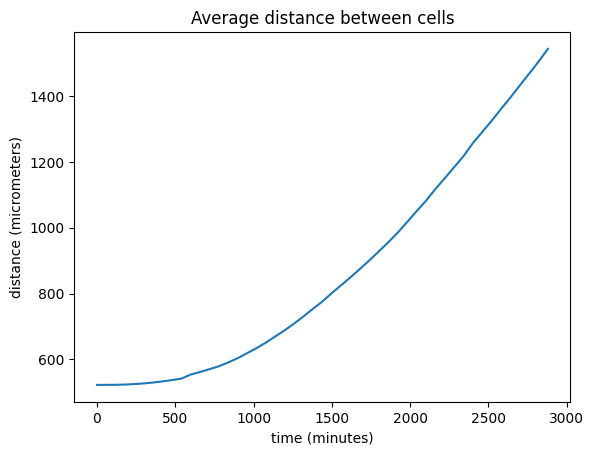

In [28]:
plt.plot(times, avg_distances)
plt.xlabel("time (minutes)")
plt.ylabel("distance (micrometers)")
plt.title("Average distance between cells")

Text(0.5, 1.0, 'Encounters between cells')

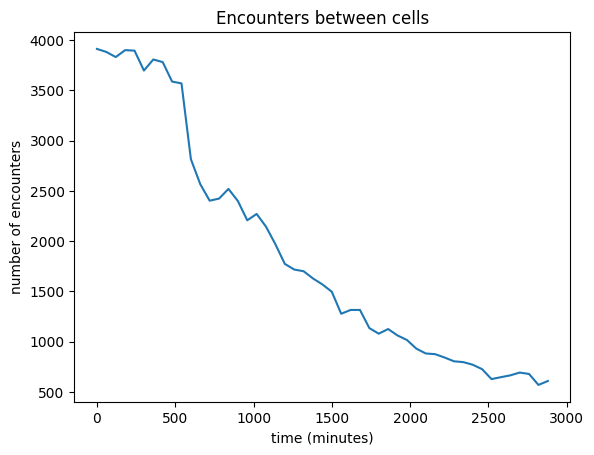

In [29]:
plt.plot(times, encounters)
plt.xlabel("time (minutes)")
plt.ylabel("number of encounters")
plt.title("Encounters between cells")